# T3032 – Traitement des signaux et données

## Partie 1 : Introduction au calcul matriciel avec Python

### Installation Dépendances et modules :
Pour que tous les modules et dépendances soient installées dans le Notebook même il faut executer la commande suivante autant de fois qu'il y a de modules :

    `!pip install monModule`

    Puis restart le kernel ou bien redémarrer VSCode / le Notebook

In [13]:
!pip install matplotlib
!pip install numpy
!pip install sounddevice
!pip install scipy


[notice] A new release of pip is available: 23.0.1 -> 24.2
[notice] To update, run: C:\Users\pc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 24.2
[notice] To update, run: C:\Users\pc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 24.2
[notice] To update, run: C:\Users\pc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 24.2
[notice] To update, run: C:\Users\pc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from scipy.io.wavfile import read
import random

### 1.1 Prise en main

**Exercice 1.1.** 
Exécutez les commandes suivantes :

In [15]:
1     # Il n'y a absolument rien qui s'affiche
2;

In [16]:
1
2;    # Comme au dessus ça ne fait absolument rien
print(3)    # Ca affiche à l'écran
print(4)

3
4


**Exercice 1.2.** Exécutez `help(np.angle)`.

Cette commande permet d'avoir des infos sur une fonction.

In [17]:
help(np.angle)    # Permet d'avoir de l'aide sur la fonction spécifiée dans les parenthèses

Help on _ArrayFunctionDispatcher in module numpy:

angle(z, deg=False)
    Return the angle of the complex argument.
    
    Parameters
    ----------
    z : array_like
        A complex number or sequence of complex numbers.
    deg : bool, optional
        Return angle in degrees if True, radians if False (default).
    
    Returns
    -------
    angle : ndarray or scalar
        The counterclockwise angle from the positive real axis on the complex
        plane in the range ``(-pi, pi]``, with dtype as numpy.float64.
    
        .. versionchanged:: 1.16.0
            This function works on subclasses of ndarray like `ma.array`.
    
    See Also
    --------
    arctan2
    absolute
    
    Notes
    -----
    This function passes the imaginary and real parts of the argument to
    `arctan2` to compute the result; consequently, it follows the convention
    of `arctan2` when the magnitude of the argument is zero. See example.
    
    Examples
    --------
    >>> import numpy

**Exercice 1.3.** Exécutez les deux commandes suivantes. Que pouvez-vous en conclure ?

In [18]:
1+2j
1+2i    # Ca sort une erreur ce qui est normal

SyntaxError: invalid decimal literal (1891297306.py, line 2)

Exécutez ensuite la commande suivante. Qu'observez-vous ?

In [1]:
1+1j    # Ca sort une erreur ce qui est normal "j" n'est pas définis
1+j

NameError: name 'j' is not defined

*Les lignes de code entrée ci-dessus ne fonctionnent pas car dans le premier cas ce n'est pas une variable décimal (le `i`) et dans le deuxième cas ça ne fonctionne pas car la variable `j` n'est pas définie.*

...

**Exercice 1.4.** Définissez deux variables `a` et `b` de la façon suivante :

In [5]:
a = 1+1j
b = 1-1j

Exécutez ensuite les instructions suivantes pour calculer le produit des deux nombres, le complexe conjugué de `a` ainsi que le module (amplitude) et l'argument (phase) de `a`. 

In [6]:
print(f"Produit de a et b : {a*b:.2f}")                    # donne le produit de a par b
print(f"Complexe conjugué de a : {a.conjugate():.2f}")     # donne le complexe conjugué de a
print(f"Module de a : {abs(a):.2f}")                       # donne le module de a
print(f"Argument de a en radians : {np.angle(a):.2f}")     # donne l'argument de a en radians

Produit de a et b : 2.00+0.00j
Complexe conjugué de a : 1.00-1.00j
Module de a : 1.41
Argument de a en radians : 0.79


*Notez qu'on utilise le symbole \# pour commenter.*

**Exercice 1.5.** Calculez le module et l'argument des nombres complexes suivants :

- $2+5j$
- $2-5j$
- $2$
- $5j$

In [11]:
c = 2+5j
d = 2-5j
e = 2
f = 5j

print(f"Module de c : {abs(c):.2f}")                       # donne le module de c
print(f"Argument de c en radians : {np.angle(c):.2f}")     # donne l'argument de c en radians

print(f"Module de c : {abs(d):.2f}")                       # donne le module de d
print(f"Argument de c en radians : {np.angle(d):.2f}")     # donne l'argument de d en radians

print(f"Module de c : {abs(e):.2f}")                       # donne le module de e
print(f"Argument de c en radians : {np.angle(e):.2f}")     # donne l'argument de e en radians

print(f"Module de c : {abs(f):.2f}")                       # donne le module de f
print(f"Argument de c en radians : {np.angle(f):.2f}")     # donne l'argument de f en radians

Module de c : 5.39
Argument de c en radians : 1.19
Module de c : 5.39
Argument de c en radians : -1.19
Module de c : 2.00
Argument de c en radians : 0.00
Module de c : 5.00
Argument de c en radians : 1.57


*Dans le cas ci-dessus on fait juste l'utilisation de fonctions fournies avec les modules*

...

**Exercice 1.6.** Comparez et commentez les résultats obtenus en calculant `np.cos(180)`, `np.cos(np.radians(180))` et `np.cos(np.deg2rad(180))`.

Les fonctions `np.rad2deg` et `np.degrees` permettent quant à elles de convertir en degrés un angle exprimé en radians.

In [2]:
print(np.cos(180))                # J'obtiens la réponse de cos 180 radians
print(np.cos(np.radians(180)))    # J'obtiens la réponse de cos 180 degrés
print(np.cos(np.deg2rad(180)))           # J'obtiens la réponse de cos 180 degrés

-0.5984600690578581
-1.0
-1.0


...

**Exercice 1.7.** Calculez les parties réelles et imaginaires des nombres complexes suivants:

1. $5\text{cjs}(\alpha)$ avec $\alpha=25$° (*rappel* : $\text{cjs}(\alpha)=\cos \alpha +j\sin\alpha)$
2. $5e^{j\alpha}$ avec $\alpha=25$° (*conseil* : utilisez la fonction `np.exp`)

Vérifiez que les valeurs obtenues aux points (1) et (2) sont égales. Ensuite, faites de même avec $7\text{cjs}(167)$.

In [25]:
alpha = 25
co = np.cos(alpha)
si = np.sin(alpha)
j = 1
cjs = co + si

print(5*cjs)

4.294255308828503


*Pour l'ex ci-dessus il faut revoir les calculs des nombres complexes*

**!! Terminer Ex 1.7 !!**

...

### 1.2 Vecteurs et matrices

**Exercice 1.8.** Il y a plusieurs façons de créer un vecteur de type `numpy.ndarray` avec Python. Exécutez les instructions suivantes :

In [26]:
t1 = np.arange(1, 11)           # définit un vecteur allant de 1 à 10
t2 = np.arange(1, 10.1, 0.1)    # définit un vecteur allant de 1 à 10 avec 
                                # un pas de 0.1
t3 = np.linspace(1, 10, 100)    # définit un vecteur contenant 100 entrées
                                # réparties uniformément entre 1 et 10
t4 = np.array([1, 3, 5, 2, -1]) # définit le vecteur en spécifiant chaque 
                                # entrée

*La deuxième instruction permet de définir le pas, c'est-à-dire la différence entre les valeurs de deux entrées successives du vecteur. La troisième instruction permet plutôt de spécifier le nombre d'entrées que l'on souhaite dans le vecteur.*

**Exercice 1.9.** Soit `t1 = np.arange(1, 11)` et `t2 = np.arange(1, 10.1, 0.1)`. Exécutez l'instruction `%whos`. Interprétez le résultat obtenu. Constatez que `t1` est un vecteur contenant 10 éléments de type `'int32'` et `t2` est un vecteur contenant 91 éléments de type `'float64'`.

In [29]:
%whos

Variable   Type        Data/Info
--------------------------------
alpha      int         25
c          complex     (2+5j)
cjs        float64     0.8588510617657006
co         float64     0.9912028118634736
d          complex     (2-5j)
e          int         2
f          complex     5j
j          int         1
np         module      <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
plt        module      <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
read       function    <function read at 0x00000205976FCDC0>
sd         module      <module 'sounddevice' fro<...>ackages\\sounddevice.py'>
si         float64     -0.13235175009777303
t1         ndarray     10: 10 elems, type `int64`, 80 bytes
t2         ndarray     91: 91 elems, type `float64`, 728 bytes
t3         ndarray     100: 100 elems, type `float64`, 800 bytes
t4         ndarray     5: 5 elems, type `int64`, 40 bytes


**Exercice 1.10.** Soit `t = np.arange(11, 21)`. Vous pouvez visualiser une ou plusieurs  entrées de `t` en procédant de différentes manières :

- `t[4]` désigne le cinquième élément du vecteur `t` ;
- `t[-1]` désigne le dernier élément du vecteur `t` ;
- `t[-2]` désigne l'avant-dernier élément du vecteur `t` ;
- `t[:5]` désigne les cinq premiers éléments du vecteur `t` ;
- `t[7:]` désigne les trois derniers éléments du vecteur `t`.

**Exercice 1.11.** Soit `t = np.arange(1, 11)`. Exécutez `print(len(t))`, `print(t.shape)`, `print(np.size(t))` et `print(np.max(t.shape))`. Interprétez les résultats au moyen de l'aide de ces fonctions.

In [4]:
t = np.arange(4, 11, 0.5)
print(len(t))
print(t.shape)
print(np.size(t))
print(np.max(t.shape))

14
(14,)
14
14


*Dans l'exercice ci-dessus on utilise des fonctions du module `numpy` pour créer et gérer des **Vecteurs***

`np.arange(number)` = définit un vecteur `t` composé de nombres entre 4 et 11 avec un pas de 0,5 (par défaut, la valeur du pas est 1).

`len(variable vecteur)` = renvoie la longueur du vecteur `variable vecteur`.

`variable.shape` OU `np.shape(variable)` = renvoie les dimensions de l’array `variable`, c’est-à-dire son nombre de lignes et son nombre de colonnes.

`np.size(variable)` = renvoie le nombre d’éléments de l’array `variable`, possiblement selon un axe donné.

`np.max(variable)` = renvoie la valeur minimum/maximum de l’array `variable`.

**Exercice 1.12.** Soit

In [10]:
x = np.array([1, 3, 7, 9, 20, 40])

Que valent : 

- `x[1]` ;
- `x[1:4]` ;
- `x[1:6:2]` ?

In [11]:
print(x[1])
print(x[1:4])
print(x[1:6:2])

3
[3 7 9]
[ 3  9 40]


(*Ici on a simplement un Array pour lequel on cherche à connaitre la valeur à tel indice*)

...

**Exercice 1.13.** Exécutez les instructions suivantes :

In [6]:
a = np.array([1, 2, 3])
b = np.array([[1], [2], [3]])

Quelle(s) différence(s) observez-vous entre les deux cas ? Lequel représente un vecteur colonne ? et un vecteur ligne ?

...

In [7]:
print(f"Vecteur Ligne : {a}")
print(f"Vecteur Colonne : {b}")

Vecteur Ligne : [1 2 3]
Vecteur Colonne : [[1]
 [2]
 [3]]


*Dans cet exercice les vecteurs sont :*

- `a = np.array([1, 2, 3])` est un vecteur représentant une ligne car celui-ci une fois transformé en un tableau NumPy, elle est interprétée comme un vecteur de taille `(3,)`, donc une seule ligne avec trois éléments.

- `b = np.array([[1], [2], [3]])` est un tableau à deux dimensions, avec trois lignes et une seule colonne. Sa forme est `(3, 1)`, ce qui en fait un vecteur colonne

**Exercice 1.14.** Une matrice est un tableau rectangulaire possédant des lignes et des colonnes. Chaque entrée du tableau contient un nombre. On peut définir une matrice en spécifiant chaque entrée de celle-ci, par exemple

In [8]:
m = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

Exécutez cette commande. Ensuite, affichez l'élément $m_{2,3}$ de la matrice `m`, c'est-à-dire l'élément localisé à la deuxième ligne et la troisième colonne.
     
On peut également afficher tout une ligne ou toute une colonne d'une matrice. Exécutez les deux instructions suivantes. Laquelle permet d'afficher la ligne 2 ? Laquelle permet d'afficher la colonne 2 ?

In [9]:
print(m[1, :])
print(m[:, 1])

[4 5 6]
[2 5 8]


*Pour afficher les éléments d'une colonne ou d'une ligne :*

- `print(m[1, :])` = permet d'afficher la 2ème ligne de la Matrice.
- `print(m[:, 1])` = permet d'afficher le 2ème élément de chaque ligne ou bien tous les éléments de la colonne 2 sous forme d'un vecteur.

...

**Exercice 1.15.** On peut concaténer plusieurs vecteurs ou matrices pour autant que leurs dimensions soient compatibles. Exécutez les instructions suivantes et observez les vecteurs ou matrices `d`, `e` et `f` résultants.

In [18]:
a = np.array([1, 2, 3])
b = np.array([[1], [2], [3]])
c = np.array([a, a])        
d = np.array([b.flatten(), b.flatten()])
e = d.T

print(f"La matrice 'a' : {a}")
print(f"La matrice 'b' : {b}")
print(f"La matrice 'c' : {c}")
print(f"La matrice 'd' : {d}")
print(f"La matrice 'e' : {e}")

La matrice 'a' : [1 2 3]
La matrice 'b' : [[1]
 [2]
 [3]]
La matrice 'c' : [[1 2 3]
 [1 2 3]]
La matrice 'd' : [[1 2 3]
 [1 2 3]]
La matrice 'e' : [[1 1]
 [2 2]
 [3 3]]


*La concaténation des Matrices peut se faire de différentes façon comme les suivantes :*

- `c = np.array([a, a])` = permet de créer une matrice `c` de matrice `a` dont les éléments de la matrice `a` vont devenir respectivement des colonnes.

- `d = np.array([b.flatten(), b.flatten()])` = la fonction `flaten()` **transforme** une matrice en un vecteur à **une** dimension.

- `e = d.T` = utilise la fonction `T` pour faire une **transposition** c'est à dire que les lignes deviennent les colonnes et les colonnes deviennent les lignes.

**Exercice 1.16.** Un signal audio est un vecteur : l'entrée d'indice $i$ correspond à l'amplitude du signal audio au temps discret $i$.

1. Ouvrez le fichier `chirac1.wav` au moyen de l'instruction `read`.

In [3]:
#Fs, s = read('sound/chirac1.wav')
Fs, s = read('C:/Users/pc/OneDrive - EPHEC asbl/Bureau/Cours/Cours 3ème/Traitements-des-signaux/Pratique/Fichiers-pour-TP/sound/chirac1.wav')


À quoi correspondent `s` et `Fs` ? Quelle est la valeur de `Fs` ? Quelles sont les valeurs maximale et minimale de `s` ?

In [18]:
print(f"La valeur de Fs est {Fs}.")
print(f"La valeur minimale de s est {np.min(s)}.")
print(f"La valeur maximale de s est {np.max(s)}.")

La valeur de Fs est 22050.
La valeur minimale de s est 41.
La valeur maximale de s est 255.


*L'exercice ci-dessus permet de lire un fichier .wav et également de connaitre :*

- `Fs` = la Fréquence d'échantillonage en Hertz (le nombre d'échantillons par seconde)

- `s` = l'échantillons audio lui même sous forme d'un tableau NumPy en **1 dimension si Mono (ex. [x1, x2, x3, ...])** et en **2 dimensions si Stéréo (ex. [[L1, R1], [L2, R2], [L3, R3], ...])** où chaque ligne représente une paire d'échantillons (gauche et droite pour chaque canal).

..

2. Écoutez ce son au moyen de l'instruction `sd.play(s)`. Celle-ci ne donne pas un résultat correct. Expliquez pourquoi. Adaptez l'instruction pour écouter le son correctement.

In [29]:
sd.play(s)

Le résultat est incorrect : le son est joué trop rapidement. La fonction n'a en effet pas l'information de la fréquence d'échantillonnage `Fs`, indispensable pour un rendu réel. Il faut alors ajouté un argument où l'on précise la **Fréquence d'échantillonage** :

In [28]:
sd.play(s, Fs)

3. Définissez un vecteur qui prend les 100 premiers éléments de `s`.
        Écoutez le résultat. Pourquoi n'entendez-vous rien ?

In [49]:
data1 = s[:100]
sd.play(data1, Fs)

On n'entend rien car la durée du signal est très courte. Ici, la durée du signal `s[:100]` est de

In [53]:
print(f"Durée du signal capturé : {(1000/22050)*100:.2f} millisecondes")

Durée du signal capturé : 4.54 millisecondes


4. Définissez un vecteur qui prend les éléments 10000 à 20000 de `s` et divise l'amplitude originale par 4 (attention, utilisez une division entière !). Écoutez le résultat.

In [13]:
data2 = s[10000:20000]
for i in s:
    i / 4

sd.play(data2, Fs)

5. Définissez un vecteur qui est la concaténation du vecteur d'indices 0 à 10000, du vecteur d'indices 10001 à 20000 et du vecteur d'indice 20001 jusqu'à l'indice du dernier élément de `s`. Écoutez le résultat obtenu.

In [45]:
data3 = s[0:10000]
data4 = s[10001:20000]
data5 = s[20001:]

data6 = np.concatenate((data3, data4, data5))

sd.play(data6, Fs)

*La sélection et concaténation de parties / échantillons d'un fichier .wav :*

- `data3 = s[0:10000]` : permet de selectionner les éléments de 0 à 10000.

- `data6 = np.concatenate((data3, data4, data5))` : permet de concatener des vecteurs en un seul vecteur.

**Exercice 1.17.** Une image en niveaux de gris (8 bits) est une matrice de nombres entiers compris entre 0 et 255.

1. Ouvrez l'image `Lenna.bmp` au moyen de la fonction `plt.imread`.
2. Visualisez l'image au moyen de la fonction `plt.imshow` suivie de `plt.show()`. Comment afficher l'image en niveaux de gris ?
3. Définissez une matrice contenant uniquement un de ses yeux.
4. Calculez la moyenne de la valeur de cette sélection à l'aide de la fonction `np.mean`.
5. Ses yeux sont-ils plutôt clairs ou foncés ?

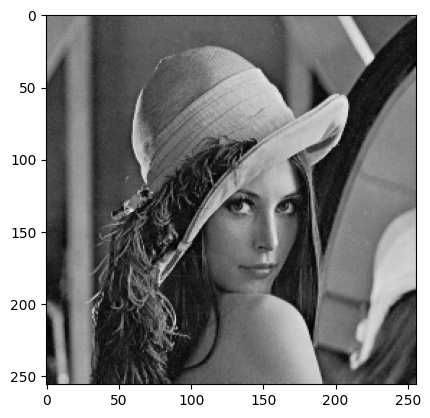

Valeur moyenne des entrées de l'array 'eyes' : 87.32


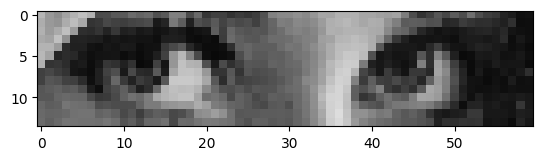

In [58]:
img1 = plt.imread("C:/Users/pc/OneDrive - EPHEC asbl/Bureau/Cours/Cours 3ème/Traitements-des-signaux/Pratique/Fichiers pour TP/Image/Lenna.bmp")

plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.show()

img1_matrice = np.array(img1)
eyes = img1_matrice[126:140, 120:180]           # Données de la matrice : img1_matrice[y1:y2, x1:x2]
img2 = plt.imshow(eyes, cmap='gray', vmin=0, vmax=255)
print(f"Valeur moyenne des entrées de l'array 'eyes' : {np.mean(eyes):.2f}")

plt.show()


*Dans cet exercice je fait du traitement, selection et affichage d'images ou partie d'image sur base de matrices :*

- `img1 = plt.imread('le chemin vers mon image')` : La fonction `plt.imread()` permet de **selectionner / charger mon image**.

- `plt.imshow(img1, cmap='gray', vmin=0, vmax=255)` : Permet de **définir des paramètres** à mon image ainsi que des contraintes.

- `plt.show()` : Permet **d'afficher l'image / le résultat**.

- `img1_matrice = np.array(img1)` : Permet de faire une **copie de mon image et la trnasformer en Matrice**.

- `eyes = img1_matrice[126:140, 120:180]` : Permet de selectionner une **partie de mon image / matrice**.

- `np.mean(eyes)` : Permet de connaitre la **valeur moyenne** des entrées de l'array que je lui passe en paramètre.

**Exercice 1.18.** Il est aussi possible de visualiser un tableau de données grâce à l'instruction `imshow`.   Visualisez un tableau de 5 lignes et 5 colonnes rempli de nombres aléatoires (vous pouvez utiliser pour cela `np.random.rand`, `np.random.randint` ou `np.random.randn`).

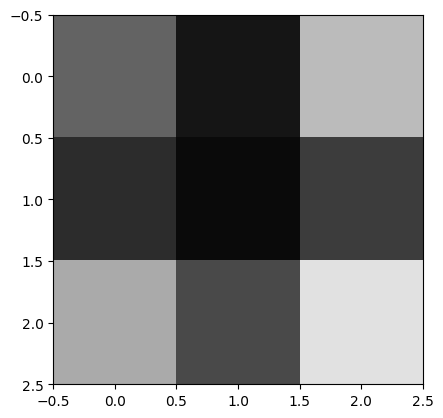

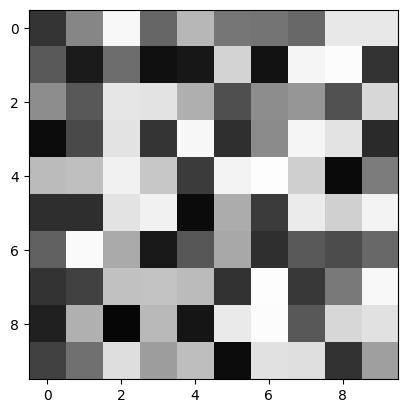

In [73]:
img_perso = np.array([[99, 21, 187],
                      [44, 10, 60],
                      [170, 73 ,225]])
plt.imshow(img_perso, cmap='gray', vmin=0, vmax=255)
plt.show()

img_perso1 = np.random.randint(1, 255, (10, 10))
plt.imshow(img_perso1, cmap='gray', vmin=0, vmax=255)

plt.show()

*Dans l'ex ci-dessus on créer une image par nous même à l'aide de Matrices comme suit :*

- `img_perso = np.array([[99, 21, 187], [44, 10, 60], [170, 73 ,225]])` : création d'une matrice de toute pièce de 3 lignes et 3 colonnes.

- `img_perso1 = np.random.randint(1, 255, (10, 10))` : création d'une matrice avec des valeurs aléatoires que je vais ensuite afficher comme image. Les 2 premiers paramètres définissent de combien à combien s'étendent les nombres aléatoires tandis ce que le 3ème parmètre définit les dimensions de l'array qui va être créer (donc le nombre de lignes et de colonnes).

### 1.3 Programmation en Python

**Exercice 1.19.** Écrivez, au moyen d'une boucle, un programme qui affiche le carré des
   nombres de 10 à 20.

In [78]:
def liste_nbr(deb, fin, pas):
    
    return np.arange(deb, fin + 1, pas)

def carre(tab):
    newtab = np.square(tab) 
    return newtab

mon_tab = liste_nbr(10, 20, 1)
tab_au_carre = carre(mon_tab)

print(f"Mon tableau de données créer : {mon_tab}")
print(f"Mon nouveau tableau avec ses données au carré : {tab_au_carre}")

Mon tableau de données créer : [10 11 12 13 14 15 16 17 18 19 20]
Mon nouveau tableau avec ses données au carré : [100 121 144 169 196 225 256 289 324 361 400]


*Dans l'ex ci-dessus on utilise simplement les fonctions déjà vue à part la suisvante :*

- `np.square(tab)` : Permet de faire le carré de l'élément qui peut être une variable ou un tableau passé en paramètre.

**Exercice 1.20.** Écrivez, au moyen d'une boucle, un programme qui donne le sinus d'un angle de 0° à 360° avec un pas de 10°.

In [92]:
degree1 = 0
sinus1 = np.sin(np.deg2rad(degree1))
angle1 = np.arange(0, 360, 10)

for i in angle1:
    print(f"Sinus : {sinus1:.2f}")
    degree1 += 10
    sinus1 = np.sin(np.deg2rad(degree1))
    print(f"Angle de degree : {degree1}")

Sinus : 0.00
Angle de degree : 10
Sinus : 0.17
Angle de degree : 20
Sinus : 0.34
Angle de degree : 30
Sinus : 0.50
Angle de degree : 40
Sinus : 0.64
Angle de degree : 50
Sinus : 0.77
Angle de degree : 60
Sinus : 0.87
Angle de degree : 70
Sinus : 0.94
Angle de degree : 80
Sinus : 0.98
Angle de degree : 90
Sinus : 1.00
Angle de degree : 100
Sinus : 0.98
Angle de degree : 110
Sinus : 0.94
Angle de degree : 120
Sinus : 0.87
Angle de degree : 130
Sinus : 0.77
Angle de degree : 140
Sinus : 0.64
Angle de degree : 150
Sinus : 0.50
Angle de degree : 160
Sinus : 0.34
Angle de degree : 170
Sinus : 0.17
Angle de degree : 180
Sinus : 0.00
Angle de degree : 190
Sinus : -0.17
Angle de degree : 200
Sinus : -0.34
Angle de degree : 210
Sinus : -0.50
Angle de degree : 220
Sinus : -0.64
Angle de degree : 230
Sinus : -0.77
Angle de degree : 240
Sinus : -0.87
Angle de degree : 250
Sinus : -0.94
Angle de degree : 260
Sinus : -0.98
Angle de degree : 270
Sinus : -1.00
Angle de degree : 280
Sinus : -0.98
Angle 

*Dans l'ex ci-dessus on créer un angle en degré qu'on va augmenter par pas de 10 en suivant un tableau qui obtient des éléments par pas de 10 de 0 à 360. On a une boucle qui va parcourir le tableau et aficher le Sinus pour l'angle donné. La fonction nouvelle et les fonctions utilisées sont les suivantes :*

- `sinus1 = np.sin(np.deg2rad(degree1))` : permet de créer un Sinus à partir de l'angle donné (*degree1*). Les angles acceptés par la fonction `np.sin(radian)` n'accepte que les radians, dans ce cas-ci on utilise la fonction `np.deg2rad(degree)` pour transformé un degré en radian.

### 1.4 Éléments de calcul matriciel

**Exercice 1.21** Créez la matrice `M=np.array([[1,2],[3,4]])` et la matrice `N` dont la première ligne vaut `2 1` et la deuxième ligne vaut `1 -1`. On pourra utiliser `N[1,:]=[2,1]`.

- Calculez `M @ N` (ou `np.matmul(M,N)`) et vérifiez théoriquement le résultat obtenu.
- Calculez `N @ M` et constatez la différence avec le résultat précédent.

In [9]:
M = np.array([[1, 2],
              [3, 4]])
N = np.array([[2, 1],
              [1, -1]])

# N[1,:] = [2, 1] # La deuxième ligne de N est égal à 

print(f"Produit Matriciel de M par N : \n {M @ N}") # Ou np.matmul(M, N)
print(f"Produit Matriciel de N par M : \n {N @ M}")

Produit Matriciel de M par N : 
 [[ 4 -1]
 [10 -1]]
Produit Matriciel de N par M : 
 [[ 5  8]
 [-2 -2]]


*Dans l'ex ci-dessus on nous présente un exemple de ce que donne le calcul d'un ***Produit Matriciel*** Explications :

- Dans le cas ci-dessus le calcul va se faire de la manière suivante pour le Produit Matriciel M par N : 

M =    et  N = 

`[1, 2]  [2, 1]`

`[3, 4]  [1, -1]`

C = 

`[(1x2 + 2x1), (1x1 + 2x(-1))]`

`[(3x2 + 4x1), (3x1 + 4x(-1))]`

Et donc est égal à :

`[ 4 -1]`

`[10 -1]`

**Exercice 1.22** Créez la matrice `O` constituée de la colonne `-2 1`. En utilisant la matrice `M` de l'exercice 1.21, calculez les matrices `M @ O` et `O @ M`. Vérifiez théoriquement le résultat obtenu.

In [10]:
O = np.array([[-2],
              [1]])

print(M @ O)
print(O @ M)

[[ 0]
 [-2]]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 1)

*Dans les 2 exs précedent on s'amuse à calculer les produits matriciel de __variable1__ par __variable2__ :*

- `M @ N` ou `np.matmul(M, N)` : Permet de calculer le produit matriciel de 2 Matrices. Elles doivent **IMPéRATIVEMENT** toutes les 2 avoir des lignes et des colonnes qui matchent c'est à dire que le nombre de lignes de A doit être égale au nombre de colonnes de B.

**Exercice 1.23** Créez une matrice `M` de taille $4\times4$ grâce à l'instruction `np.ones`.
Remplacez la deuxième colonne de cette matrice par des `2` et remplacez la troisième ligne du résultat par des `3`. Affichez le résultat. Créez ensuite une matrice `I` de taille $4\times4$ contenant des `1` sur la diagonale principale et des `0` partout ailleurs. Cette matrice est une <i>matrice identité</i>. Vous pouvez utiliser la fonction `np.eye` ou la construire à partir de la fonction `np.zeros`.

- Calculez `M @ I` et `I @ M`. Que pouvez-vous en conclure ?
- Calculez `F = M + I` puis `G = np.linalg.inv(F)` (<i>inverse</i> de `F`) et `F @ G`. Que pouvez-vous en conclure ?
- La matrice `M` possède-t-elle une inverse ?

In [11]:
M = np.ones((4, 4)) # Créer une matrice de 4 par 4 composée de 1 partout
M[:,1] = 2 # Remplacer la 2ème colonne par des 2
M[2,:] = 3 # Remplacer la 3ème ligne par des 3
print(f"Matrice M = \n {M}")

I = np.eye(4, 4) # Créer une matrice de 4 par 4 composée de 0 à l'exception de la diagonale principale par des 1
print(f"Matrice I = \n {I}")
print(f"La diagonale ressemble à ceci : {np.diag(I)}")

print(f"M par I donne : \n {M @ I}")
print(f"I par M donne : \n {I @ M}")

F = M + I
G = np.linalg.inv(F)    # Renvoie la matrice inverse de F si elle existe

print(f"F par G donne : \n {F @ G}")

Matrice M = 
 [[1. 2. 1. 1.]
 [1. 2. 1. 1.]
 [3. 3. 3. 3.]
 [1. 2. 1. 1.]]
Matrice I = 
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
La diagonale ressemble à ceci : [1. 1. 1. 1.]
M par I donne : 
 [[1. 2. 1. 1.]
 [1. 2. 1. 1.]
 [3. 3. 3. 3.]
 [1. 2. 1. 1.]]
I par M donne : 
 [[1. 2. 1. 1.]
 [1. 2. 1. 1.]
 [3. 3. 3. 3.]
 [1. 2. 1. 1.]]
F par G donne : 
 [[ 1.00000000e+00 -1.11022302e-16 -1.38777878e-17  2.22044605e-16]
 [-1.38777878e-17  1.00000000e+00 -1.38777878e-17  0.00000000e+00]
 [-4.16333634e-17  0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 8.32667268e-17 -1.11022302e-16 -2.77555756e-17  1.00000000e+00]]


***Pour l'ex ci-dessus : J'AI RIEN COMPRIS A LA MATIERE JE DOIS LA REVOIR + EN DETAIL***

**Exercice 1.24** En plus de la matrice `M` obtenue à la fin de l'exercice 1.23, créez une matrice `C` de deux lignes et de 4 colonnes, `C = np.array([[0, 1, 2, 3], [3, 4, 5, 6]])`.

- Calculez `M @ C` et `C @ M`. Pourquoi obtient-on une erreur avec `M @ C` ?
- Calculez `C.T` (<i>transposée</i> de `C`) et `M @ C.T`. Pourquoi n'obtient-on pas d'erreur en calculant `M.T @ C.T` ?

In [12]:
C = np.array([[0, 1, 2, 3], [3, 4, 5, 6]])

print(f"C par M donne : \n {C @ M}")
# print(f"M par C donne : \n {M @ C}") # Génère une erreur ! C'est normal mais POURQUOI ? Car le nombre de ligne de M est supérieur au nombre de colonnes de C

print(f"La transposée de C : \n {C.T}")
print(f"Le produit matriciel de M par la transposée de C : \n {M @ C.T}")
print(f"Le produit matriciel de la transposée de M par la transposée de C : \n {M.T @ C.T}")

C par M donne : 
 [[10. 14. 10. 10.]
 [28. 41. 28. 28.]]
La transposée de C : 
 [[0 3]
 [1 4]
 [2 5]
 [3 6]]
Le produit matriciel de M par la transposée de C : 
 [[ 7. 22.]
 [ 7. 22.]
 [18. 54.]
 [ 7. 22.]]
Le produit matriciel de la transposée de M par la transposée de C : 
 [[10. 28.]
 [14. 41.]
 [10. 28.]
 [10. 28.]]


***Pour l'ex ci-dessus : J'AI RIEN COMPRIS A LA MATIERE JE DOIS LA REVOIR + EN DETAIL***

**Exercice 1.25** Soit la matrice `M` obtenue à l'exercice 1.23.

- Calculez `np.linalg.matrix_power(M, 2)` et `M @ M`. Comparez les résultats obtenus.
- Calculez `np.square(M)` et `M * M` et comparez au résultat du point précédent.

In [5]:
print(f"Linéaire alg matrix power de M : \n {np.linalg.matrix_power(M,2)}")     # Renvoie le carré de la matrice M. C'est égal à M * M
print(f"Le produit matriciel de M par M : \n {M @ M}")

print(f"Le carre de M : \n {np.square(M)}")     # Renvoie une matrice dans laquelle chaque éléments de M a été mis au carré. Egal à M * M
print(f"Le produit de M par M : \n {M * M}")    # Renvoie pareil que np.square() et np.linalg.matrix_power()

Linéaire alg matrix power de M : 
 [[ 7 10]
 [15 22]]
Le produit matriciel de M par M : 
 [[ 7 10]
 [15 22]]
Le carre de M : 
 [[ 1  4]
 [ 9 16]]
Le produit de M par M : 
 [[ 1  4]
 [ 9 16]]


**Exercice 1.26** L'opération `*`, par exemple `x * y`, donne un multiplication terme à terme des deux facteurs. Si l'un d'eux est un scalaire, il multiplie tous les termes de l'autre sinon `x` et `y` doivent avoir la même dimension. En utilisant les matrices définies dans les exercices précédents,

- calculez  `M * I`, `2 * M` et `C * M` et expliquez vos réponses ;
- interprétez `len(variable)` et `variable.shape` pour `M`, `I` et `C`.

In [13]:
print(f"M multiplié par I : \n {M * I}")    # Multiplie M par I
print(f"Multiplication par 2 de M : \n {2 * M}")    # Multiplie tous les éléments de M par 2
# print(f"C multiplié par M : \n {C * M}")    # Donne une erreur car pas le même nombre de lignes

print(f"Longueur de M : {len(M)}")  # Renvoie le nombre de lignes que contient la matrice
print(f"Longueur de I : {len(I)}")
print(f"Longueur de C : {len(C)}")

print(f"Nombre éléments de M : {M.shape}")  # Renvoie le nombre de lignes et de colonnes que contient la matrice
print(f"Nombre éléments de I : {I.shape}")
print(f"Nombre éléments de C : {C.shape}")

M multiplié par I : 
 [[1. 0. 0. 0.]
 [0. 2. 0. 0.]
 [0. 0. 3. 0.]
 [0. 0. 0. 1.]]
Multiplication par 2 de M : 
 [[2. 4. 2. 2.]
 [2. 4. 2. 2.]
 [6. 6. 6. 6.]
 [2. 4. 2. 2.]]
Longueur de M : 4
Longueur de I : 4
Longueur de C : 2
Nombre éléments de M : (4, 4)
Nombre éléments de I : (4, 4)
Nombre éléments de C : (2, 4)


**Exercice 1.27** Écrivez un programme qui affiche le carré des nombres de 10 à 20 sans
    utiliser de boucle.
<br>ATTENTION ! Les calculs faisant intervenir des boucles sont en général très lents. Il est donc beaucoup plus efficace d'utiliser des outils de calcul matriciel. VOIR NOTE DANS LE CAHIER DE LABO !!

In [14]:
nbr_initial = np.arange(10, 20 + 1, 1)

nbr_carre = np.square(nbr_initial)

print(f"Nombre initial = {nbr_initial}")
print(f"Nombre carre = {nbr_carre}")

Nombre initial = [10 11 12 13 14 15 16 17 18 19 20]
Nombre carre = [100 121 144 169 196 225 256 289 324 361 400]
